Using CatDog from the PCA project directory

In [5]:
# Core libraries
import numpy as np
from pathlib import Path
from PIL import Image
import random
import matplotlib.pyplot as plt

def list_images(folder):
    """Return all image paths (jpg, jpeg, png) in a folder."""
    exts = {".jpg", ".jpeg", ".png"}
    return [p for p in folder.glob("*") if p.suffix.lower() in exts]

def load_image(path, size):
    """Load, resize, convert to RGB, normalize [0,1]."""
    with Image.open(path) as im:
        im = im.convert("RGB").resize(size)
        arr = np.asarray(im, dtype=np.float32) / 255.0
        return arr

def load_dataset(
    data_dir="../PCA/CatDog", 
    img_size=(64,64), 
    val_split=0.2, 
    seed=42
):
    """
    Loads CatDog dataset from folder structure:
      ../PCA/CatDog/cat/*.jpg
      ../PCA/CatDog/dog/*.jpg

    Returns:
      train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes
    Shapes:
      train_set_x_orig: (m_train, height, width, 3)
      train_set_y: (1, m_train)
    """
    random.seed(seed)
    np.random.seed(seed)

    data_dir = Path(data_dir)
    cat_dir = data_dir
    dog_dir = data_dir
    assert cat_dir.exists(), f"Missing folder: {cat_dir}"
    assert dog_dir.exists(), f"Missing folder: {dog_dir}"

    cat_paths = list_images(cat_dir)
    dog_paths = list_images(dog_dir)

    data = [(p, 0) for p in cat_paths] + [(p, 1) for p in dog_paths]
    random.shuffle(data)

    # Load all images
    X = np.stack([load_image(p, img_size) for p, _ in data])
    y = np.array([lbl for _, lbl in data], dtype=np.int32)

    # Split into train/test
    n_test = int(len(y) * val_split)
    X_test, y_test = X[:n_test], y[:n_test]
    X_train, y_train = X[n_test:], y[n_test:]

    train_set_x_orig = X_train
    train_set_y = y_train.reshape(1, -1)
    test_set_x_orig = X_test
    test_set_y = y_test.reshape(1, -1)
    classes = np.array(["cat", "dog"])

    return train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes


In [2]:
train_set_x_orig, train_set_y, test_set_x_orig, test_set_y, classes = load_dataset()

print("train_set_x_orig shape:", train_set_x_orig.shape)
print("train_set_y shape:", train_set_y.shape)
print("test_set_x_orig shape:", test_set_x_orig.shape)
print("Classes:", classes)


train_set_x_orig shape: (176, 64, 64, 3)
train_set_y shape: (1, 176)
test_set_x_orig shape: (44, 64, 64, 3)
Classes: ['cat' 'dog']


In [3]:
m_train = train_set_x_orig.shape[0]
m_test = test_set_x_orig.shape[0]

train_set_x_flatten = train_set_x_orig.reshape(m_train, -1).T
test_set_x_flatten = test_set_x_orig.reshape(m_test, -1).T

train_set_x = train_set_x_flatten / 1.0
test_set_x = test_set_x_flatten / 1.0

print("train_set_x shape:", train_set_x.shape)
print("test_set_x shape:", test_set_x.shape)


train_set_x shape: (12288, 176)
test_set_x shape: (12288, 44)


Visualize a few samples:

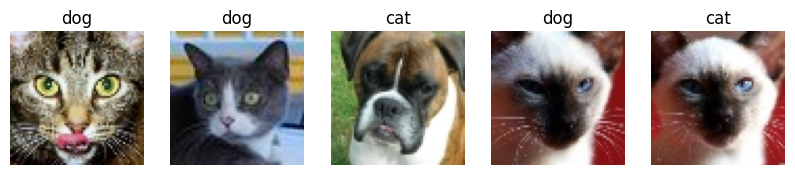

In [6]:
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(train_set_x_orig[i])
    label = classes[int(train_set_y[0,i])]
    plt.title(label)
    plt.axis('off')
plt.show()


# 🧠 Logistic Regression Implementation (Step by Step)

In this section, we’ll implement the **Logistic Regression algorithm from scratch** using **NumPy**.  

Our goal is to train a simple binary classifier that can distinguish **cats 🐱 (label = 0)** from **dogs 🐶 (label = 1)**.

We will implement the following functions:

1. `initialize_with_zeros(dim)`  
2. `sigmoid(z)`  
3. `propagate(w, b, X, Y)`  
4. `optimize(w, b, X, Y, num_iterations, learning_rate)`  
5. `predict(w, b, X)`  
6. `model(X_train, Y_train, X_test, Y_test, ...)`

---

## 1️⃣ Initialize Parameters

We first need to initialize our parameters **\( w \)** and **\( b \)**.

- **\( w \)**: weight vector of shape \((n_x, 1)\)
- **\( b \)**: bias term (scalar)

We initialize both with zeros (you could also use small random values, but zeros are fine for logistic regression).

The **sigmoid** (or logistic) function is the key activation used in logistic regression.  
It maps any real-valued input \( z \in \mathbb{R} \) into the range \((0,1)\),  
which can be interpreted as a **probability**.

### 🧭 Definition

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

- When \( z \to +\infty \), \( \sigma(z) \to 1 \)  
- When \( z \to -\infty \), \( \sigma(z) \to 0 \)  
- When \( z = 0 \), \( \sigma(0) = 0.5 \)

This property makes it ideal for **binary classification**,  
where the output represents the probability of belonging to class 1.


In [10]:
def initialize_with_zeros(dim):
    w = np.zeros((dim, 1))
    b = 0.0
    return w, b

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


## 3️⃣ Forward & Backward Propagation

Now that we’ve defined our **sigmoid activation**,  
we can build the **core of logistic regression** — the forward and backward pass.

The goal here is to:

1. **Forward Propagate:**  
   - Compute the predicted output (activation)  
   - Evaluate the **cost function** (how wrong we are)

2. **Backward Propagate:**  
   - Compute the **gradients** (partial derivatives)  
   - Update parameters using **Gradient Descent**

---

### 🧭 Step 1: Forward Propagation

Given:
- Training data $X \in \mathbb{R}^{n_x \times m}$
- Labels $Y \in \{0,1\}^{1 \times m}$
- Parameters $w \in \mathbb{R}^{n_x \times 1}, \, b \in \mathbb{R}$

We compute:

$$
Z = w^T X + b
$$

$$
A = \sigma(Z)
$$

where:
- $Z$ is the **linear combination**
- $A$ is the **activation**, interpreted as $P(y=1|x)$

---

### 🧭 Step 2: Compute the Cost

We use the **Binary Cross-Entropy** (Log Loss):

$$
J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log a^{(i)} + (1 - y^{(i)}) \log (1 - a^{(i)}) \Big]
$$

This measures how close our predicted probabilities $A$ are to the true labels $Y$.

---

### 🧭 Step 3: Backward Propagation (Gradients)

We compute the derivatives:

$$
\frac{\partial J}{\partial w} = \frac{1}{m} X (A - Y)^T
$$

$$
\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (A^{(i)} - Y^{(i)})
$$

These gradients tell us how to update $w$ and $b$ to reduce the cost.

---

### 🧠 Summary

- **Forward pass:** computes cost  
- **Backward pass:** computes gradients (`dw`, `db`)


In [ ]:
def propagate(w, b, X, Y):
    m = X.shape[1]
    A = sigmoid(np.dot(w.T, X) + b)
    cost = (-1/m) * np.sum(Y*np.log(A + 1e-9) + (1-Y)*np.log(1 - A + 1e-9))
    
    dw = (1/m) * np.dot(X, (A - Y).T)
    db = (1/m) * np.sum(A - Y)
    
    grads = {"dw": dw, "db": db}
    return grads, cost


## 4️⃣ Optimization — Gradient Descent

Now that we can compute the **cost** and **gradients** from forward & backward propagation,  
we can use them to **update our parameters** $w$ and $b$ and minimize the loss function.

This process is called **Gradient Descent**.

---

### 🧭 The Goal

We want to find parameters $(w, b)$ that **minimize** the cost function:

$$
J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[ y^{(i)} \log a^{(i)} + (1 - y^{(i)}) \log(1 - a^{(i)}) \Big]
$$

At each iteration, we move $w$ and $b$ in the **opposite direction** of the gradient  
(to go “downhill” in the cost function):

---

### ⚙️ Update Rules

The parameters are updated using the following equations:

$$
w := w - \alpha \frac{\partial J}{\partial w}
$$

$$
b := b - \alpha \frac{\partial J}{\partial b}
$$

where:

- $\alpha$ = **learning rate** (controls step size)
- $\frac{\partial J}{\partial w}$ and $\frac{\partial J}{\partial b}$ = **gradients**

---


In [ ]:
def optimize(w, b, X, Y, num_iterations, learning_rate, print_cost=False):
    costs = []
    for i in range(num_iterations):
        grads, cost = propagate(w, b, X, Y)
        dw, db = grads["dw"], grads["db"]
        
        w -= learning_rate * dw
        b -= learning_rate * db
        
        if i % 100 == 0:
            costs.append(cost)
            if print_cost:
                print(f"Cost after iteration {i}: {cost:.4f}")
    return {"w": w, "b": b}, grads, costs



## 5️⃣ Prediction Function

Once our model is trained, we can use the learned parameters $w$ and $b$  
to make predictions on **new data**.

---

### 🧭 Goal

Given an input $X$, we want to predict the label $\hat{Y}$.

We first compute the **predicted probability** using the sigmoid function:

$$
A = \sigma(w^T X + b)
$$

This gives us a **value between 0 and 1** — the estimated probability that the label is 1 (e.g., **dog**).

---

### 🧠 Decision Rule

To convert probabilities into **binary predictions**, we apply a **threshold**:

$$
\hat{Y} =
\begin{cases}
1, & \text{if } A \ge 0.5 \\
0, & \text{if } A < 0.5
\end{cases}
$$

- If $A \ge 0.5$ → predict **dog (1)**
- If $A < 0.5$ → predict **cat (0)**

---

In [12]:
def predict(w, b, X):
    A = sigmoid(np.dot(w.T, X) + b)
    Y_pred = (A > 0.5).astype(int)
    return Y_pred

def model(X_train, Y_train, X_test, Y_test, num_iterations=2000, learning_rate=0.005, print_cost=False):
    w, b = initialize_with_zeros(X_train.shape[0])
    params, grads, costs = optimize(w, b, X_train, Y_train, num_iterations, learning_rate, print_cost)
    
    w, b = params["w"], params["b"]
    
    Y_pred_train = predict(w, b, X_train)
    Y_pred_test = predict(w, b, X_test)
    
    print(f"train accuracy: {100 - np.mean(np.abs(Y_pred_train - Y_train))*100:.2f}%")
    print(f"test accuracy: {100 - np.mean(np.abs(Y_pred_test - Y_test))*100:.2f}%")
    
    d = {
        "costs": costs,
        "Y_prediction_test": Y_pred_test,
        "Y_prediction_train": Y_pred_train,
        "w": w,
        "b": b,
        "learning_rate": learning_rate,
        "num_iterations": num_iterations
    }
    return d

## 6️⃣ Full Training Pipeline — `model()`

Now we’ll **tie everything together** into a single function `model()` that:
1) initializes parameters,  
2) optimizes them with gradient descent,  
3) predicts on train/test sets, and  
4) reports accuracies and returns artifacts.

---

### 🧭 Objective

Minimize the **binary cross-entropy** cost
$$
J(w,b) = -\frac{1}{m} \sum_{i=1}^{m} \Big[y^{(i)} \log a^{(i)} + (1-y^{(i)})\log(1-a^{(i)})\Big],
$$
where \( a^{(i)} = \sigma(w^\top x^{(i)} + b) \).

---

### 🎯 Metrics

We use **accuracy**:
$$
\text{Accuracy} = 1 - \frac{1}{m}\sum_{i=1}^m \mathbf{1}\{\hat y^{(i)} \ne y^{(i)}\}.
$$

---

In [13]:
d = model(
    X_train=train_set_x,
    Y_train=train_set_y,
    X_test=test_set_x,
    Y_test=test_set_y,
    num_iterations=2000,
    learning_rate=0.005,
    print_cost=True
)


Cost after iteration 0: 0.6931
Cost after iteration 100: 1.2641
Cost after iteration 200: 1.2003
Cost after iteration 300: 1.1537
Cost after iteration 400: 1.1180
Cost after iteration 500: 1.0891
Cost after iteration 600: 1.0649
Cost after iteration 700: 1.0441
Cost after iteration 800: 1.0259
Cost after iteration 900: 1.0098
Cost after iteration 1000: 0.9955
Cost after iteration 1100: 0.9827
Cost after iteration 1200: 0.9713
Cost after iteration 1300: 0.9609
Cost after iteration 1400: 0.9516
Cost after iteration 1500: 0.9432
Cost after iteration 1600: 0.9355
Cost after iteration 1700: 0.9285
Cost after iteration 1800: 0.9222
Cost after iteration 1900: 0.9164
train accuracy: 60.80%
test accuracy: 6.82%


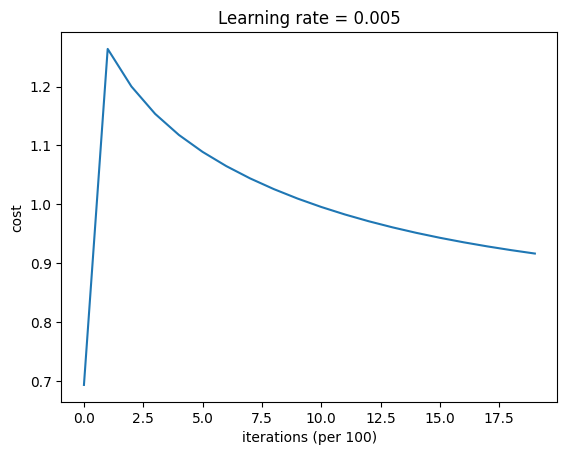

In [14]:
costs = np.squeeze(d["costs"])
import matplotlib.pyplot as plt
plt.plot(costs)
plt.ylabel("cost")
plt.xlabel("iterations (per 100)")
plt.title(f"Learning rate = {d['learning_rate']}")
plt.show()


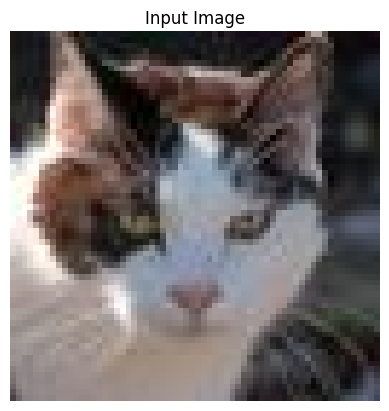

✅ Model prediction: cat 🐱


In [19]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

# 🔹 Choose your image path
img_path = "../PCA/CatDog/cat (45).jpg"  # or "../PCA/CatDog/cat/cat (1).jpg"

# 🔹 Load and preprocess
image = Image.open(img_path).convert("RGB").resize((64, 64))
plt.imshow(image)
plt.axis('off')
plt.title("Input Image")
plt.show()

# 🔹 Convert to NumPy array and normalize
x_single = np.asarray(image, dtype=np.float32) / 255.0

# 🔹 Flatten and reshape to match model input (n_x, 1)
x_single = x_single.reshape(-1, 1)

# 🔹 Predict
y_hat = predict(d["w"], d["b"], x_single)
label = "dog 🐶" if y_hat == 1 else "cat 🐱"
print(f"✅ Model prediction: {label}")



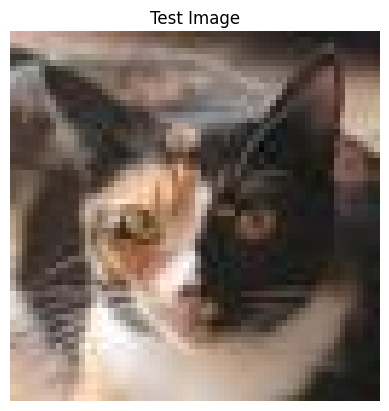

y = 0, we predicted that it is a "dog" picture.


In [22]:
# Example of a picture that was wrongly classified
index = 1  # choose an index from your test set
num_px = test_set_x_orig.shape[1]  # e.g. 64

# Show the image
plt.imshow(test_set_x_orig[index])
plt.axis('off')
plt.title("Test Image")
plt.show()

# Ground truth and prediction
true_label = int(test_set_y[0, index])
pred_label = int(d['Y_prediction_test'][0, index])

print(f"y = {true_label}, we predicted that it is a \"{classes[pred_label]}\" picture.")
